Using Ragas for evaluation: https://docs.ragas.io/en/latest/getstarted/index.html

In [2]:
import sys
print(sys.executable)

/Users/prashantsharma/GitHub/Unlocking-Data-with-Generative-AI-and-RAG-Second-Edition/.venv/bin/python3.10


In [5]:
%pip install --upgrade pip

# Uninstall conflicting packages
%pip uninstall -y langchain_classic langchain-core langchain-openai langchain-community langchain chromadb beautifulsoup4 python-dotenv PyPDF2 rank_bm25

# Install compatible versions of langchain-core and langchain-openai
%pip install langchain-community==0.4.1
%pip install langchain-text-splitters==1.0.0
%pip install langchain-openai==1.1.0
%pip install langsmith==0.4.49
%pip install langchain==1.1.0

# Install remaining packages
%pip install langchain-chroma==1.0.0
%pip install chromadb==1.3.5
%pip install python-dotenv==1.2.1
%pip install PyPDF2==3.0.1 -q
%pip install rank_bm25==0.2.2
%pip uninstall uvloop -y

# new
%pip install ragas==0.4.0
%pip install tqdm==4.67.1 -q
%pip install matplotlib==3.10.7

  Using cached pip-26.1.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_core-1.4.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached langchain_classic-1.0.7-py3-none-any.whl.metadata (5.1 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached aiohttp-3.13.5-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached pydantic_settings-2.14.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached http

In [3]:
import os
os.environ['USER_AGENT'] = 'RAGUserAgent'
import openai
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_chroma import Chroma
import chromadb
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from PyPDF2 import PdfReader
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

## new
import tqdm as notebook_tqdm
import pandas as pd
import matplotlib.pyplot as plt
from ragas import EvaluationDataset, SingleTurnSample, evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.testset import TestsetGenerator
from ragas.testset.synthesizers.single_hop.specific import SingleHopSpecificQuerySynthesizer
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    FactualCorrectness,
    ResponseRelevancy,
    LLMContextPrecisionWithoutReference,
    SemanticSimilarity
)

In [4]:
# variables
_ = load_dotenv(dotenv_path='env.txt')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
openai.api_key = os.environ['OPENAI_API_KEY']
embedding_function = OpenAIEmbeddings()
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)
pdf_path = "google-2023-environmental-report.pdf"
collection_name = "google_environmental_report"
str_output_parser = StrOutputParser()
user_query = "What are Google's environmental initiatives?"

In [5]:
# LLMs/Embeddings
embedding_ada = "text-embedding-ada-002"
model_gpt4omini = "gpt-4o-mini"
model_gpt4o = "gpt-4o"

embedding_function = OpenAIEmbeddings(model=embedding_ada, openai_api_key=openai.api_key)
llm = ChatOpenAI(model=model_gpt4omini, openai_api_key=openai.api_key, temperature=0.0)

# Generator LLM for testset generation
generator_llm_raw = ChatOpenAI(model=model_gpt4omini, openai_api_key=openai.api_key, temperature=0.0)
generator_llm = LangchainLLMWrapper(generator_llm_raw)
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model=embedding_ada, openai_api_key=openai.api_key))

# Critic LLM for evaluation
critic_llm_raw = ChatOpenAI(model=model_gpt4o, openai_api_key=openai.api_key, temperature=0.0)
embeddings_raw = OpenAIEmbeddings(model=embedding_ada, openai_api_key=openai.api_key)
critic_llm_wrapped = LangchainLLMWrapper(critic_llm_raw)
embeddings_wrapped = LangchainEmbeddingsWrapper(embeddings_raw)


/var/folders/4p/vfy2gbxn3wjbbshckh9hrhq40000gn/T/ipykernel_59346/1903404535.py:11: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  generator_llm = LangchainLLMWrapper(generator_llm_raw)
/var/folders/4p/vfy2gbxn3wjbbshckh9hrhq40000gn/T/ipykernel_59346/1903404535.py:12: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model=embedding_ada, openai_api_key=openai.api_key))
/var/folders/4p/vfy2gbxn3wjbbshckh9hrhq40000gn/T/ipykernel_59346/1903404535.py:17: Deprecat

In [6]:
#### INDEXING ####

In [7]:
# # Load the PDF and extract text
pdf_reader = PdfReader(pdf_path)
text = ""
for page in pdf_reader.pages:
    text += page.extract_text()

In [8]:
# Split
character_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1000,
    chunk_overlap=200
)
splits = character_splitter.split_text(text)

In [9]:
dense_documents = [Document(page_content=text, metadata={"id": str(i), "source": "dense"}) for i, text in enumerate(splits)]
sparse_documents = [Document(page_content=text, metadata={"id": str(i), "source": "sparse"}) for i, text in enumerate(splits)]

In [10]:
chroma_client = chromadb.Client()
vectorstore = Chroma.from_documents(
    documents=dense_documents,
    embedding=embedding_function,
    collection_name=collection_name,
    client=chroma_client
)

In [11]:
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
sparse_retriever = BM25Retriever.from_documents(sparse_documents, k=10)
ensemble_retriever = EnsembleRetriever(retrievers=[dense_retriever, sparse_retriever], weights=[0.5, 0.5], c=0)

In [12]:
#### RETRIEVAL and GENERATION ####

In [13]:
# Prompt
client = Client()
prompt = client.pull_prompt("jclemens24/rag-prompt")

/Users/prashantsharma/GitHub/Unlocking-Data-with-Generative-AI-and-RAG-Second-Edition/.venv/lib/python3.10/site-packages/langsmith/client.py:7775: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  prompt = loads(json.dumps(prompt_object.manifest))


In [14]:
# Relevance check prompt
relevance_prompt_template = PromptTemplate.from_template(
    """
    Given the following question and retrieved context, determine if the context is relevant to the question.
    Provide a score from 1 to 5, where 1 is not at all relevant and 5 is highly relevant.
    Return ONLY the numeric score, without any additional text or explanation.

    Question: {question}
    Retrieved Context: {retrieved_context}

    Relevance Score:"""
)

In [15]:
# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [16]:
def extract_score(llm_output):
    try:
        score = float(llm_output.strip())
        return score
    except ValueError:
        return 0

# Chain it all together with LangChain
def conditional_answer(x):
    relevance_score = extract_score(x['relevance_score'])
    if relevance_score < 4:
        return "I don't know."
    else:
        return x['answer']

In [17]:
rag_chain_from_docs = (
    RunnablePassthrough.assign(context=(lambda x: format_docs(x["context"])))
    | RunnableParallel(
        {"relevance_score": (
            RunnablePassthrough()
            | (lambda x: relevance_prompt_template.format(question=x['question'], retrieved_context=x['context']))
            | llm
            | str_output_parser
        ), "answer": (
            RunnablePassthrough()
            | prompt
            | llm
            | str_output_parser
        )}
    )
    | RunnablePassthrough().assign(final_answer=conditional_answer)
)

In [18]:
rag_chain_similarity = RunnableParallel(
    {"context": dense_retriever,
     "question": RunnablePassthrough()
}).assign(answer=rag_chain_from_docs)

In [19]:
rag_chain_hybrid = RunnableParallel(
    {"context": ensemble_retriever,
     "question": RunnablePassthrough()
}).assign(answer=rag_chain_from_docs)

In [20]:

# Question - Submitted to the similarity / dense vector search
result = rag_chain_similarity.invoke(user_query)
retrieved_docs = result['context']

print(f"Original Question to Similarity Search: {user_query}\n")
print(f"Relevance Score: {result['answer']['relevance_score']}\n")
print(f"Final Answer:\n{result['answer']['final_answer']}\n\n")
print("Retrieved Documents:")
for i, doc in enumerate(retrieved_docs, start=1):
    print(f"Document {i}: Document ID: {doc.metadata['id']} source: {doc.metadata['source']}")
    print(f"Content:\n{doc.page_content}\n")

Original Question to Similarity Search: What are Google's environmental initiatives?

Relevance Score: 5

Final Answer:
Google's environmental initiatives focus on three key pillars: empowering individuals, working together with partners and customers, and operating sustainably. Some specific initiatives include:

1. **Empowering Individuals**: Google aims to help 1 billion people make more sustainable choices through features like eco-friendly routing in Google Maps, energy efficiency in Google Nest thermostats, and carbon emissions information in Google Flights.

2. **Sustainable Operations**: Google has committed to achieving net-zero carbon emissions and operates its Bay View campus, which is all-electric and net water-positive. The campus also incorporates principles of circular design.

3. **Collaboration and Partnerships**: Google is involved in various coalitions and initiatives, such as the iMasons Climate Accord for carbon reduction in digital infrastructure and the ReFED Cat

In [21]:
# Question - Submitted to the hybrid / multi-vector search
result = rag_chain_hybrid.invoke(user_query)
retrieved_docs = result['context']

print(f"Original Question to Dense Search: {user_query}\n")
print(f"Relevance Score: {result['answer']['relevance_score']}\n")
print(f"Final Answer:\n{result['answer']['final_answer']}\n\n")
print("Retrieved Documents:")
for i, doc in enumerate(retrieved_docs, start=1):
    print(f"Document {i}: Document ID: {doc.metadata['id']} source: {doc.metadata['source']}")
    print(f"Content:\n{doc.page_content}\n")

Original Question to Dense Search: What are Google's environmental initiatives?

Relevance Score: 5

Final Answer:
Google's environmental initiatives include:

1. **Empowering Individuals**: Google aims to help 1 billion people make more sustainable choices through features like eco-friendly routing in Google Maps, energy efficiency in Google Nest thermostats, and carbon emissions information in Google Flights.

2. **Working Together**: Google collaborates with partners and customers to advance technology for sustainability, including initiatives like the iMasons Climate Accord and funding for food waste solutions through the ReFED Catalytic Grant Fund.

3. **Operating Sustainably**: Google has committed to achieving net-zero carbon emissions and operates its Bay View campus as an all-electric, net water-positive facility. They also focus on circular economy principles and engage with suppliers to reduce their energy consumption and greenhouse gas emissions.

4. **Water Stewardship**: 

#### SIMILARITY SEARCH ONLY
Google's environmental initiatives include empowering individuals to take action, working together with partners and customers, operating sustainably, achieving net-zero carbon emissions, water stewardship, and promoting a circular economy. They have implemented sustainability features in products like Google Maps, Google Nest thermostats, and Google Flights to help individuals make more sustainable choices. Google also supports various environmental organizations and initiatives, such as the iMasons Climate Accord, ReFED, and The Nature Conservancy, to accelerate climate action and address environmental challenges. Additionally, Google is involved in public policy advocacy and is committed to reducing its environmental impact through its operations and value chain.


#### HYBRID SEARCH

Google's environmental initiatives include empowering individuals to take action, working together with partners and customers, operating sustainably, achieving net-zero carbon emissions, focusing on water stewardship, promoting a circular economy, engaging with suppliers to reduce energy consumption and greenhouse gas emissions, and reporting environmental data. They also support public policy and advocacy for low-carbon economies, participate in initiatives like the iMasons Climate Accord and ReFED, and support projects with organizations like The Nature Conservancy. Additionally, Google is involved in initiatives with the World Business Council for Sustainable Development and the World Resources Institute to improve well-being for people and the planet. They are also working on using technology and platforms to organize information about the planet and make it actionable to help partners and customers create a positive impact.

### SYNTHETIC DATA GENERATION

In [22]:
# Create generator with wrapped LLMs
generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings
)

In [24]:
# Prepare documents
documents = [Document(page_content=chunk) for chunk in splits]

# Define query distribution (only single-hop)
query_distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 1.0),
]

# Generate testset

testset = generator.generate_with_langchain_docs(
    documents,
    testset_size=10,
    query_distribution=query_distribution
)

Applying SummaryExtractor:   0%|          | 0/444 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/453 [00:00<?, ?it/s]

Node 0b68be75-900a-484f-a842-0bd6c7ca95f2 does not have a summary. Skipping filtering.
Node 8d660f65-1085-469b-9e6f-588ef5549eea does not have a summary. Skipping filtering.
Node ae2624ac-a18b-4438-900b-b5ace25a9ef3 does not have a summary. Skipping filtering.
Node 6ac8ddad-f1f2-4093-8145-8981fddeed84 does not have a summary. Skipping filtering.
Node e2f50489-e66e-47b5-8b2f-716c70b2a96b does not have a summary. Skipping filtering.
Node fe9d1a4a-2354-4999-b609-663cbf038300 does not have a summary. Skipping filtering.
Node af29bc00-061b-4755-87cd-6eadb44678e5 does not have a summary. Skipping filtering.
Node 432857b4-9405-4c0b-b77a-30debd434233 does not have a summary. Skipping filtering.
Node 01d62ea5-b5b2-496a-861b-0369f5a858e2 does not have a summary. Skipping filtering.


Applying EmbeddingExtractor:   0%|          | 0/444 [00:00<?, ?it/s]

Applying ThemesExtractor:   0%|          | 0/453 [00:00<?, ?it/s]

...

Applying CosineSimilarityBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

In [25]:
# comparison dataframe
testset_df = testset.to_pandas()

# save dataframes to CSV files in the specified directory
testset_df.to_csv(os.path.join('testset_data.csv'), index=False)

print("testset DataFrame saved successfully in the local directory.")

testset DataFrame saved successfully in the local directory.


In [26]:
# pull data from saved testset, rather than generating above

### load dataframs from CSV file
saved_testset_df = pd.read_csv(os.path.join('testset_data.csv'))
print("testset DataFrame loaded successfully from local directory.")
saved_testset_df.head(5)

testset DataFrame loaded successfully from local directory.


,user_input,reference_contexts,reference,persona_name,query_style,query_length,synthesizer_name
0,Whts in the 2023 enviromental report?,['Environmental \nReport\n2023What’s \ninside\...,Google’s 2023 Environmental Report provides an...,Renewable Energy Analyst,MISSPELLED,SHORT,single_hop_specific_query_synthesizer
1,What is Google's approach to sustainability?,['Highlights 6\nOur sustainability strategy 7...,Google's approach to sustainability includes o...,Sustainable Development Manager,PERFECT_GRAMMAR,SHORT,single_hop_specific_query_synthesizer
2,What is the role of Googol in sustainability g...,['About Google\n 76\nSustainab i\nlity governa...,The context does not provide specific informat...,Sustainable Development Manager,MISSPELLED,MEDIUM,single_hop_specific_query_synthesizer
3,How has the understanding of Learning and Sust...,['4\n2023 Environmental Report \nExecutive le...,"Since the late 1980s, the understanding of Lea...",Sustainable Development Manager,PERFECT_GRAMMAR,SHORT,single_hop_specific_query_synthesizer
4,How Google get to carbon neutrality and what t...,"['I worked on Search for 20 years, leading the...","Google achieved carbon neutrality in 2007, whi...",Sustainable Development Manager,POOR_GRAMMAR,LONG,single_hop_specific_query_synthesizer


### PREPARE SIMILARITY SEARCH DATASET

In [27]:
# PREPARE EVALUATION DATASETS
# Function to generate samples
def generate_ragas_sample(question, ground_truth, rag_chain):
    result = rag_chain.invoke(question)
    
    return SingleTurnSample(
        user_input=question,
        response=result["answer"]["final_answer"],
        retrieved_contexts=[doc.page_content for doc in result["context"]],
        reference=ground_truth
    )


### EVAL SETS FOR EACH CHAIN

In [28]:
# Generate samples for similarity search
similarity_samples = []
for _, row in saved_testset_df.iterrows():
    try:
        sample = generate_ragas_sample(
            row["user_input"], 
            row["reference"],
            rag_chain_similarity
        )
        similarity_samples.append(sample)
    except Exception as e:
        print(f"Error: {e}")
        continue

evaluation_dataset_similarity = EvaluationDataset(samples=similarity_samples)

In [31]:
# Generate samples for hybrid search
hybrid_samples = []
for _, row in saved_testset_df.iterrows():
    try:
        sample = generate_ragas_sample(
            row["user_input"], 
            row["reference"],
            rag_chain_hybrid
        )
        hybrid_samples.append(sample)
    except Exception as e:
        print(f"Error: {e}")
        continue

evaluation_dataset_hybrid = EvaluationDataset(samples=hybrid_samples)

### EVAL SCORING

In [29]:
# Initialize metrics with wrapped LLMs
metrics = [
    Faithfulness(llm=critic_llm_wrapped),
    ResponseRelevancy(llm=critic_llm_wrapped, embeddings=embeddings_wrapped),
    LLMContextPrecisionWithoutReference(llm=critic_llm_wrapped),
    LLMContextRecall(llm=critic_llm_wrapped),
    FactualCorrectness(llm=critic_llm_wrapped),
    SemanticSimilarity(embeddings=embeddings_wrapped)
]

In [30]:
# Evaluate similarity search
print("Evaluating similarity search...")
score_similarity = evaluate(
    dataset=evaluation_dataset_similarity,
    metrics=metrics
)

similarity_df = score_similarity.to_pandas()
similarity_df

Evaluating similarity search...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[32]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-lo6tB58supaJycVjCC7LlTk9 on tokens per min (TPM): Limit 30000, Used 29619, Requested 1646. Please try again in 2.53s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}})
Exception raised in Job[14]: TimeoutError()
Exception raised in Job[18]: TimeoutError()
Exception raised in Job[20]: TimeoutError()
Exception raised in Job[24]: TimeoutError()
Exception raised in Job[26]: TimeoutError()
Exception raised in Job[27]: TimeoutError()
Exception raised i

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,llm_context_precision_without_reference,context_recall,factual_correctness(mode=f1),semantic_similarity
0,Whts in the 2023 enviromental report?,[Environmental \nReport\n2023What’s \ninside\n...,The 2023 Environmental Report from Google prov...,Google’s 2023 Environmental Report provides an...,1.000000,0.924396,0.704861,1.0,0.38,0.966919
1,What is Google's approach to sustainability?,[that Google can make a meaningful difference ...,Google's approach to sustainability is organiz...,Google's approach to sustainability includes o...,1.000000,0.963239,0.500000,1.0,0.00,0.928463
2,What is the role of Googol in sustainability g...,[in partnership with the Egyptian government a...,Googol plays a significant role in sustainabil...,The context does not provide specific informat...,1.000000,0.966918,NaN,0.0,0.00,0.838417
3,How has the understanding of Learning and Sust...,[4\n2023 Environmental Report \nExecutive let...,"Since the late 1980s, the understanding of Lea...","Since the late 1980s, the understanding of Lea...",NaN,1.000000,NaN,1.0,0.76,0.970397
4,How Google get to carbon neutrality and what t...,[in four key ways: accelerating the transition...,Google has achieved carbon neutrality and is a...,"Google achieved carbon neutrality in 2007, whi...",NaN,0.927648,NaN,NaN,0.32,0.907320
5,How do we achive carbon-free enery?,[2023 Environmental Report Advancing carbon-f...,"To achieve carbon-free energy, we can follow s...","To achieve carbon-free energy, we have set a b...",NaN,0.943101,NaN,NaN,0.11,0.870730
6,How can Google's mission contribute to address...,"[Beyond our own footprint, Google’s founding m...","Google's mission to ""organize the world’s info...",Google’s founding mission—'Organize the world’...,NaN,1.000000,NaN,NaN,0.40,0.965611
7,How does the Search feature contribute to maki...,"[In 2022, we worked with the IEA to rapidly de...",The Search feature contributes to making infor...,"The Search feature, along with other products ...",NaN,1.000000,0.750000,1.0,0.31,0.900795
8,How Google Trends help in understanding trends?,"[Given the scale of the problem, innovation w...",Google Trends helps in understanding trends by...,Google Trends insights are featured in the 202...,0.500000,0.953008,0.583333,1.0,0.40,0.915149
9,How is California contributing to sustainabili...,"[Moving ahead, we’ll continue to build partner...",California is contributing to sustainability e...,The context mentions that the speaker grew up ...,0.846154,1.000000,0.200000,1.0,0.25,0.859449


In [32]:
# Evaluate hybrid search
print("Evaluating hybrid search...")
score_hybrid = evaluate(
    dataset=evaluation_dataset_hybrid,
    metrics=metrics
)

hybrid_df = score_hybrid.to_pandas()
hybrid_df

Evaluating hybrid search...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[6]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[2]: TimeoutError()
Exception raised in Job[8]: TimeoutError()
Exception raised in Job[14]: TimeoutError()
Exception raised in Job[18]: TimeoutError()
Exception raised in Job[20]: TimeoutError()
Exception raised in Job[24]: TimeoutError()
Exception raised in Job[26]: TimeoutError()
Exception raised in Job[27]: TimeoutError()
Exception raised in Job[30]: TimeoutError()
Exception raised in Job[32]: TimeoutError()
Exception raised in Job[33]: TimeoutError()
Exception raised in Job[36]: TimeoutError()
Exception raised in Job[38]: TimeoutError()
Exception raised in Job[39]: TimeoutError()
Exception raised in Job[42]: TimeoutError()
Exception

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,llm_context_precision_without_reference,context_recall,factual_correctness(mode=f1),semantic_similarity
0,Whts in the 2023 enviromental report?,[Environmental \nReport\n2023What’s \ninside\n...,The 2023 Environmental Report from Google prov...,Google’s 2023 Environmental Report provides an...,0.75,0.924396,NaN,1.0,0.55,0.967215
1,What is Google's approach to sustainability?,[135 \nPreserving nature is critical both to m...,Google's approach to sustainability focuses on...,Google's approach to sustainability includes o...,NaN,1.000000,NaN,1.0,0.29,0.923589
2,What is the role of Googol in sustainability g...,[in partnership with the Egyptian government a...,Googol plays a significant role in sustainabil...,The context does not provide specific informat...,NaN,0.943233,NaN,0.0,0.00,0.853570
3,How has the understanding of Learning and Sust...,[4\n2023 Environmental Report \nExecutive let...,"Since the late 1980s, the understanding of Lea...","Since the late 1980s, the understanding of Lea...",NaN,1.000000,NaN,1.0,0.44,0.973247
4,How Google get to carbon neutrality and what t...,[in four key ways: accelerating the transition...,Google has achieved carbon neutrality and is a...,"Google achieved carbon neutrality in 2007, whi...",NaN,0.921630,NaN,NaN,0.32,0.895227
5,How do we achive carbon-free enery?,[2023 Environmental Report Advancing carbon-f...,"To achieve carbon-free energy, we can follow s...","To achieve carbon-free energy, we have set a b...",NaN,0.944813,NaN,NaN,0.12,0.868004
6,How can Google's mission contribute to address...,"[Beyond our own footprint, Google’s founding m...","Google's mission to ""organize the world’s info...",Google’s founding mission—'Organize the world’...,NaN,0.981696,NaN,NaN,0.42,0.967734
7,How does the Search feature contribute to maki...,"[information in these moments, we’re providing...",The Search feature contributes to making infor...,"The Search feature, along with other products ...",NaN,1.000000,NaN,NaN,0.33,0.902688
8,How Google Trends help in understanding trends?,"[Given the scale of the problem, innovation w...",I don't know.,Google Trends insights are featured in the 202...,NaN,0.000000,0.000000,NaN,0.00,0.734368
9,How is California contributing to sustainabili...,"[Moving ahead, we’ll continue to build partner...",California is contributing to sustainability e...,The context mentions that the speaker grew up ...,NaN,0.983774,0.133333,1.0,0.12,0.854236


### ANALYSIS

In [33]:
# ANALYSIS
key_columns = [
    'faithfulness',
    'answer_relevancy',
    'llm_context_precision_without_reference',
    'context_recall',
    'factual_correctness(mode=f1)',
    'semantic_similarity'
]

similarity_means = similarity_df[key_columns].mean()
hybrid_means = hybrid_df[key_columns].mean()

comparison_df = pd.DataFrame({
    'Similarity Run': similarity_means, 
    'Hybrid Run': hybrid_means
})
comparison_df['Difference'] = comparison_df['Similarity Run'] - comparison_df['Hybrid Run']

# Save dataframes
similarity_df.to_csv(os.path.join('similarity_run_data.csv'), index=False)
hybrid_df.to_csv(os.path.join('hybrid_run_data.csv'), index=False)
comparison_df.to_csv(os.path.join('comparison_data.csv'), index=True)

print("Dataframes saved successfully in the local directory.")

Dataframes saved successfully in the local directory.


In [34]:
# Load and print comparison
sem_df = pd.read_csv(os.path.join('similarity_run_data.csv'))
rec_df = pd.read_csv(os.path.join('hybrid_run_data.csv'))
comparison_df = pd.read_csv(os.path.join('comparison_data.csv'), index_col=0)

print("Dataframes loaded successfully from the local directory.")
print("Performance Comparison:")
print("\n**Retrieval**:")
print(comparison_df.loc[['llm_context_precision_without_reference', 'context_recall']])
print("\n**Generation**:")
print(comparison_df.loc[['faithfulness', 'answer_relevancy']])
print("\n**End-to-end evaluation**:")
print(comparison_df.loc[['factual_correctness(mode=f1)', 'semantic_similarity']])

Dataframes loaded successfully from the local directory.
Performance Comparison:

**Retrieval**:
                                         Similarity Run  Hybrid Run  \
llm_context_precision_without_reference        0.547639    0.066667   
context_recall                                 0.857143    0.800000   

                                         Difference  
llm_context_precision_without_reference    0.480972  
context_recall                             0.057143  

**Generation**:
                  Similarity Run  Hybrid Run  Difference
faithfulness            0.869231    0.750000    0.119231
answer_relevancy        0.967831    0.869954    0.097877

**End-to-end evaluation**:
                              Similarity Run  Hybrid Run  Difference
factual_correctness(mode=f1)        0.293000    0.259000    0.034000
semantic_similarity                 0.912325    0.893988    0.018337


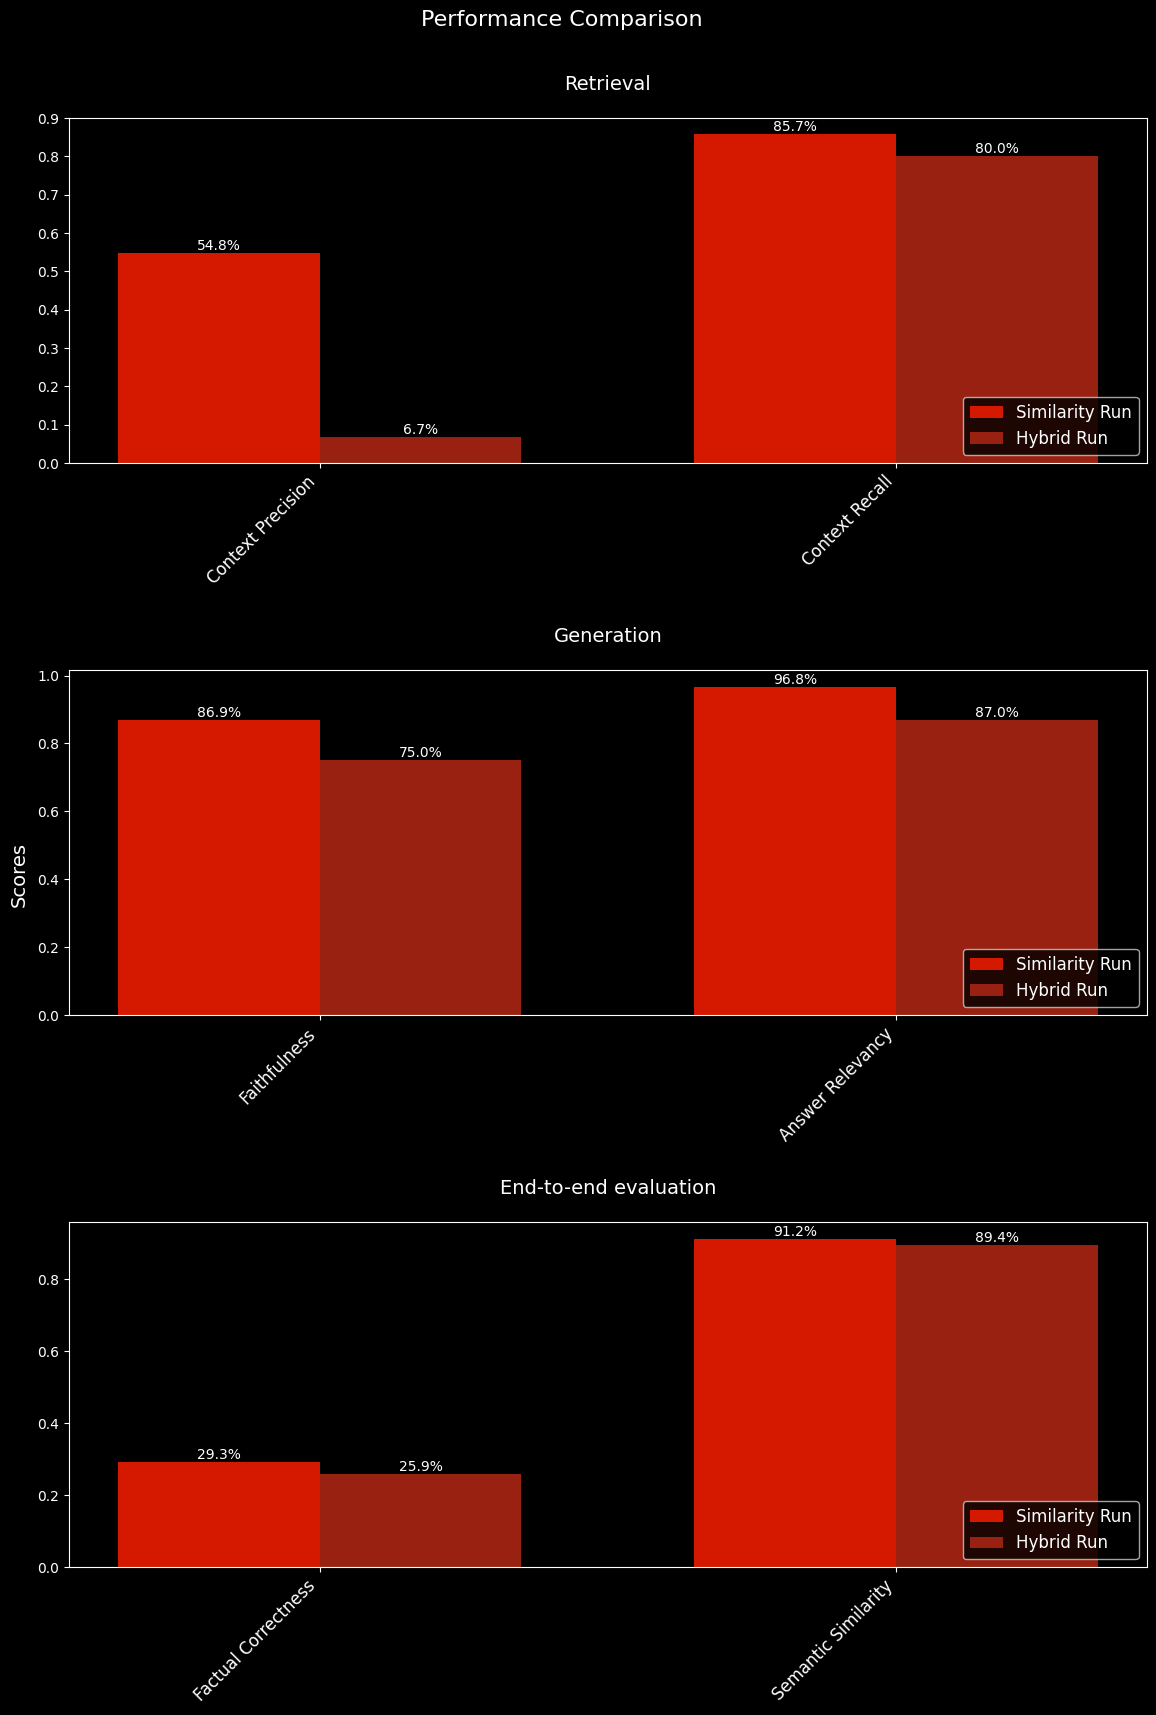

In [35]:
# Visualization - Using actual column names from the dataframe
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)
bar_width = 0.35
categories = ['Retrieval', 'Generation', 'End-to-end evaluation']
metrics_list = [
    ['llm_context_precision_without_reference', 'context_recall'],
    ['faithfulness', 'answer_relevancy'],
    ['factual_correctness(mode=f1)', 'semantic_similarity']
]

for i, (category, metric_list) in enumerate(zip(categories, metrics_list)):
    ax = axes[i]
    x = range(len(metric_list))
    
    similarity_bars = ax.bar(
        x, 
        comparison_df.loc[metric_list, 'Similarity Run'], 
        width=bar_width, 
        label='Similarity Run', 
        color='#D51900'
    )
    
    for bar in similarity_bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height, 
            f'{height:.1%}', 
            ha='center', 
            va='bottom', 
            fontsize=10
        )
    
    hybrid_bars = ax.bar(
        [i + bar_width for i in x], 
        comparison_df.loc[metric_list, 'Hybrid Run'], 
        width=bar_width, 
        label='Hybrid Run', 
        color='#992111'
    )
    
    for bar in hybrid_bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height, 
            f'{height:.1%}', 
            ha='center', 
            va='bottom', 
            fontsize=10
        )
    
    ax.set_title(category, fontsize=14, pad=20)
    ax.set_xticks([i + bar_width / 2 for i in x])
    
    # Simplify the labels for display
    display_labels = []
    for label in metric_list:
        if label == 'llm_context_precision_without_reference':
            display_labels.append('Context Precision')
        elif label == 'context_recall':
            display_labels.append('Context Recall')
        elif label == 'answer_relevancy':
            display_labels.append('Answer Relevancy')
        elif label == 'factual_correctness(mode=f1)':
            display_labels.append('Factual Correctness')
        else:
            display_labels.append(label.replace('_', ' ').title())
    
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=12)
    ax.legend(fontsize=12, loc='lower right', bbox_to_anchor=(1, 0))

fig.text(0.04, 0.5, 'Scores', va='center', rotation='vertical', fontsize=14)
fig.suptitle('Performance Comparison', fontsize=16)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.6, top=0.92)
plt.show()